# DL-ROM baseline vs Laplace AE — compression temporelle

**But du notebook.** Mettre en valeur la **compression temporelle** obtenue par la
transformée de Laplace, en comparant la baseline **DL-ROM** (Fresca et al. 2021, *sans*
Laplace) aux autoencodeurs Laplace **LLAE** et **SLAE**, au niveau **surrogate** (`θ → U(t)`).

## Message scientifique

La transformée de Laplace **découple la compression temporelle de la précision**.

- Le **DL-ROM** n'a qu'un seul levier pour réduire son coût temporel : **sous-échantillonner
  le temps** (`Nt ↓`, via `data.t_stride=κ`, à horizon `T=150 s` **fixe**, donc `Δt → κ·Δt`).
  Sa sortie n'a alors que `Nt_eff` pas. Son surrogate a `K = Nt` têtes → coût **`O(Nt)`**.
- **Laplace** comprime le temps **spectralement** (`Nt=150 → K=16`) sans jeter d'information :
  la trajectoire complète (150 pas) est reconstruite par la transformée inverse `L⁻¹`. Son
  surrogate a `K = 16` têtes → coût **`O(K)`**, indépendant de la résolution demandée.

**La claim = perf × coût.** À budget de params apparié (`Nt≈15` ≈ LLAE `K=16`, ~3 M),
Laplace **sort les 150 pas** que le DL-ROM ne fournit qu'au plein `Nt=150` (×6.8 params),
pour une précision comparable. On **ne prétend pas** que Laplace a une erreur plus basse
dans l'absolu — le message porte sur le **coût à résolution de sortie donnée**.

## Métrique — **iso-grille**, sans interpolation

Chaque modèle est jugé sur **sa propre grille native** : prédiction vs vérité
sous-échantillonnée `U[::κ]` (DL-ROM `Nt_eff` pas ; Laplace `κ=1` → 150 pas vs `U`). C'est
exactement `scripts/evaluate.py`. **Aucune interpolation** n'est faite (pas de comparaison
« iso-horizon » : ré-interpoler une sortie grossière fausserait la comparaison). La
**résolution de sortie** (15 vs 150 pas) est portée explicitement par la colonne `Nt` /
l'annotation des figures, pas par la métrique.

> **Préconditions.** Tourner là où `dataset/ch4_rotated.npy` + `dataset/doe_rotated.npy` +
> `dataset/split.npz` et les checkpoints **surrogate** (`DLROMModel__…`, `LLAEModel__…`,
> `SLAEModel__…`) sont présents. Checkpoints absents →
> `hf download keyvanatt/laplace-autoencoders-checkpoints --local-dir checkpoints`.
> Le notebook se **dégrade proprement** si une famille est absente.

In [1]:
import sys, os
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')
sys.path.insert(0, os.path.join('..', 'src'))

import glob
import re
import gc
import numpy as np
import torch
import torch.nn.functional as F_nn
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from tqdm.auto import tqdm

from laplace_surrogate.inference.pipeline import InferencePipeline

/users/eleves-b/2023/keyvan.attarian/diffusion_ae/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuration (paramétrable)

Liste des `Nt` du sweep DL-ROM et références Laplace. **Toutes** les variantes `K=16`
listées sont incluses (pas de priorité/fallback) : `_ll` (LLAE pôles appris, `g0.0`) / `_ol`
(SLAE contour optimisé, `g0.0`) **et** la variante nue « classique » (`g0.01`, sans suffixe).
Les deux extensions `.pt` **et** `.ckpt` sont globbées ; les motifs absents sont ignorés.

In [2]:
# ── DL-ROM : sweep Nt (un checkpoint entraîné par résolution) ────────────────
#    DL-ROM ne sort que son Nt natif → il FAUT un modèle par point.
NT_LIST   = [150, 75, 50, 30, 15]          # checkpoints DL-ROM disponibles
NT_FULL   = 150                            # horizon complet (nb de pas natif du dataset)

# ── Grille de résolutions de sortie pour le sweep « coût vs Nt » ─────────────
#    Les pipelines Laplace (SLAE/LLAE) sortent n'importe quel Nt depuis UN SEUL
#    checkpoint K=16 (predict(..., n_frames=Nt) / generate(Nt=...)) — horizon T conservé.
NT_GRID   = [15, 30, 50, 75, 150]

# ── Références Laplace : TOUTES les variantes listées sont incluses ──────────
#    _ll = pôles appris (LLAE, g0.0) / _ol = contour optimisé (SLAE, g0.0)
#    nue  = basis fixe « classique » (g0.01, sans suffixe)
LLAE_REFS = [
    'LLAEModel__llae_ld64_K16_g0.0_ll__t*',   # pôles appris
    'LLAEModel__llae_ld64_K16_g0.01__t*',     # basis fixe « classique » (g0.01)
]
SLAE_REFS = [
    'SLAEModel__slae_ld64_K16_g0.0_ol__t*',   # contour optimisé hors-ligne
    'SLAEModel__slae_ld64_K16_g0.01__t*',     # basis fixe « classique » (g0.01)
]

POD_REF_MEDIAN = 8.91      # médiane L2rel (%) du meilleur POD surrogate (article §8)

DATA_PATH  = '../dataset/ch4_rotated.npy'
DOE_PATH   = '../dataset/doe_rotated.npy'
SPLIT_PATH = '../dataset/split.npz'
CKPT_DIR   = '../checkpoints'
CACHE_DIR  = 'cache_dlrom'
N          = 128
DT         = 1.0

os.makedirs(CACHE_DIR, exist_ok=True)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


## 2. Chargement du dataset (repris de `eval_surrogates`)

`N=128`, resize bilinéaire. `θ=(k,A,C)` depuis `doe_rotated`. `split.npz → test_idx`.

In [3]:
# Raw field data (mmap)
U_raw = np.load(DATA_PATH, mmap_mode='r')          # (ns, Nt, H, W)
ns, Nt_full, H, W = U_raw.shape
print(f'Dataset: {ns} sims, Nt={Nt_full}, {H}×{W}')
assert Nt_full == NT_FULL, f'Attendu Nt={NT_FULL}, trouvé {Nt_full}'

# Physical parameters θ = (k, A, C)
doe = np.load(DOE_PATH)
theta_np = np.stack([doe['k'], doe['A'], doe['C']], axis=1).astype(np.float32)  # (ns, 3)
print(f'θ shape: {theta_np.shape}  min={theta_np.min():.3f}  max={theta_np.max():.3f}')

# Train/test split
split     = np.load(SPLIT_PATH)
test_idx  = split['test_idx'].tolist()
train_idx = [i for i in range(ns) if i not in set(test_idx)]
print(f'Train: {len(train_idx)}  Test: {len(test_idx)}')

Dataset: 8100 sims, Nt=150, 128×128
θ shape: (8100, 3)  min=0.000  max=350.000
Train: 6480  Test: 1620


In [4]:
def load_u(idx: int) -> np.ndarray:
    '''Load and resize U to (Nt, N, N) float32 (full 150-step horizon).'''
    u = U_raw[idx].astype(np.float32)
    if u.shape[-1] != N:
        u_t = torch.from_numpy(u).unsqueeze(1)
        u_t = F_nn.interpolate(u_t, size=(N, N), mode='bilinear', align_corners=False)
        u   = u_t.squeeze(1).numpy()
    return u

## 3. Découverte robuste des checkpoints

Conventions de nommage (fichiers `.pt` **ou** `.ckpt`) :

- **DL-ROM** : `DLROMModel__dlrom_ld64_Nt{Nt}__t*`, `Nt ∈ {150,75,50,30,15}`.
- **LLAE réfs** : `llae_ld64_K16` — `g0.0_ll` (pôles appris) + `g0.01` (nue « classique »).
- **SLAE réfs** : `slae_ld64_K16` — `g0.0_ol` (contour optimisé) + `g0.01` (nue « classique »).

Toutes les variantes présentes sont ajoutées. Tolérant à l'absence : logue ce qui est
trouvé / ignoré, ne crashe jamais.

In [5]:
def _glob_both(stem_pattern: str) -> list:
    '''Glob un motif de stem (sans extension) sur .pt ET .ckpt, trié.'''
    hits = []
    for ext in ('.pt', '.ckpt'):
        hits += glob.glob(os.path.join(CKPT_DIR, stem_pattern + ext))
    return sorted(set(hits))


def _collect_refs(patterns: list, label: str) -> list:
    '''Renvoie TOUS les checkpoints existants parmi les motifs listés (déduplos,
    ordre des motifs préservé). Logue chaque motif trouvé / absent. Jamais de crash.'''
    found, seen = [], set()
    for pat in patterns:
        hits = _glob_both(pat)
        if hits:
            for h in hits:                       # tous les hits (ex. -v1, -v2)
                if h not in seen:
                    seen.add(h); found.append(h)
                    print(f'  [{label}] retenu   : {os.path.basename(h)}')
        else:
            print(f'  [{label}] absent   : {pat}(.pt|.ckpt)')
    if not found:
        print(f'  [{label}] AUCUNE référence trouvée → famille ignorée dans les figures.')
    return found


# ── DL-ROM sweep ─────────────────────────────────────────────────────────────
print('DL-ROM sweep :')
dlrom_paths = {}    # Nt_nominal → path
for nt in NT_LIST:
    hits = _glob_both(f'DLROMModel__dlrom_ld64_Nt{nt}__t*')
    if hits:
        dlrom_paths[nt] = hits[-1]
        print(f'  [Nt={nt:>3}] {os.path.basename(hits[-1])}')
    else:
        print(f'  [Nt={nt:>3}] absent   : DLROMModel__dlrom_ld64_Nt{nt}__t*(.pt|.ckpt)')

# ── Références Laplace (toutes les variantes listées) ────────────────────────
print('\nRéférences Laplace :')
llae_refs = _collect_refs(LLAE_REFS, 'LLAE')
slae_refs = _collect_refs(SLAE_REFS, 'SLAE')

# ── Table de travail : name → path (ordre : DL-ROM par Nt ↓, puis réfs) ──────
ckpt_paths = {}
for nt in sorted(dlrom_paths, reverse=True):
    p = dlrom_paths[nt]
    ckpt_paths[os.path.splitext(os.path.basename(p))[0]] = p
for p in (*llae_refs, *slae_refs):
    ckpt_paths[os.path.splitext(os.path.basename(p))[0]] = p

print(f'\n{len(ckpt_paths)} checkpoint(s) à évaluer :')
for n in ckpt_paths:
    print('  ', n)
if not ckpt_paths:
    print('\n*** Aucun checkpoint surrogate trouvé. '
          'Ce notebook doit tourner sur le host GPU distant (voir préconditions). ***')

DL-ROM sweep :
  [Nt=150] DLROMModel__dlrom_ld64_Nt150__t4h2.ckpt
  [Nt= 75] DLROMModel__dlrom_ld64_Nt75__t4h2.ckpt
  [Nt= 50] DLROMModel__dlrom_ld64_Nt50__t4h2.ckpt
  [Nt= 30] DLROMModel__dlrom_ld64_Nt30__t4h2.ckpt
  [Nt= 15] DLROMModel__dlrom_ld64_Nt15__t4h2.ckpt

Références Laplace :
  [LLAE] retenu   : LLAEModel__llae_ld64_K16_g0.0_ll__t4h2.ckpt
  [LLAE] retenu   : LLAEModel__llae_ld64_K16_g0.01__t4h2.ckpt
  [SLAE] retenu   : SLAEModel__slae_ld64_K16_g0.0_ol__t4h2.ckpt
  [SLAE] retenu   : SLAEModel__slae_ld64_K16_g0.01__t4h2.ckpt

9 checkpoint(s) à évaluer :
   DLROMModel__dlrom_ld64_Nt150__t4h2
   DLROMModel__dlrom_ld64_Nt75__t4h2
   DLROMModel__dlrom_ld64_Nt50__t4h2
   DLROMModel__dlrom_ld64_Nt30__t4h2
   DLROMModel__dlrom_ld64_Nt15__t4h2
   LLAEModel__llae_ld64_K16_g0.0_ll__t4h2
   LLAEModel__llae_ld64_K16_g0.01__t4h2
   SLAEModel__slae_ld64_K16_g0.0_ol__t4h2
   SLAEModel__slae_ld64_K16_g0.01__t4h2


## 4. Palette & noms lisibles

`PALETTE` reçoit `'DLROMModel'` ; le sweep utilise en plus une **colormap par `Nt`**.
`_pretty_name` / `_SURR_PAT` sont étendus pour parser `dlrom_ld*_Nt*` (le regex de
`eval_surrogates` ne matchait que slae/llae/lslae).

In [6]:
PALETTE = {
    'SLAEModel'       : 'steelblue',
    'SLAESVDModel'    : '#7CA6D8',
    'SLAETuckerModel' : '#2B4C7E',
    'LLAEModel'       : 'tomato',
    'LLAESVDModel'    : '#F0946E',
    'LLAETuckerModel' : '#8C2B14',
    'DLROMModel'      : '#4C9A2A',   # vert — baseline sans Laplace
    'CorrectionAE'    : '#55A868',
}

# Colormap par Nt pour le sweep DL-ROM (Nt petit = coût faible = clair).
DLROM_CMAP = plt.get_cmap('viridis')

def dlrom_color(nt_eff: int, nt_list=None) -> tuple:
    '''Couleur d'un point DL-ROM selon son Nt effectif (léger→foncé).'''
    nts = sorted(nt_list or NT_LIST)
    frac = (nts.index(nt_eff) / max(len(nts) - 1, 1)) if nt_eff in nts else 0.5
    return DLROM_CMAP(0.15 + 0.7 * frac)


# AE stem Laplace, e.g. 'llae_ld64_K16_g0.1_ll' / 'slae_ld64_K16_g0.1_ol'
_AE_STEM_PAT = re.compile(
    r'^(?P<ae>slae|llae|lslae)_ld(?P<ld>\d+)_K(?P<K>\d+)_g(?P<g>[0-9.]+)(?P<ae_suf>.*)$'
)
# AE stem DL-ROM, e.g. 'dlrom_ld64_Nt75'
_AE_STEM_DLROM_PAT = re.compile(r'^dlrom_ld(?P<ld>\d+)_Nt(?P<Nt>\d+)$')

# Surrogate ckpt, e.g. 'DLROMModel__dlrom_ld64_Nt75__t4h2' or
# 'LLAEModel__llae_ld64_K16_g0.1_ll__t4h2[-v1]'
_SURR_PAT = re.compile(
    r'^(?P<cls>[A-Za-z]+Model)__(?P<ae_stem>.+?)__'
    r't(?P<n_trunk>\d+)h(?P<n_head>\d+)(?P<suffix>.*?)(?:-v(?P<ver>\d+))?$'
)


def _fmt_g(g: str) -> str:
    f = float(g)
    return str(int(f)) if f == int(f) else str(f)


def _pretty_name(name: str) -> str:
    '''Nom lisible sur deux lignes. Gère DL-ROM (dlrom_ld*_Nt*) et Laplace.'''
    m = _SURR_PAT.match(name)
    if not m:
        return name
    ae_stem = m.group('ae_stem')

    # ── DL-ROM ───────────────────────────────────────────────────────────────
    dm = _AE_STEM_DLROM_PAT.match(ae_stem)
    if dm:
        nt = int(dm.group('Nt'))
        return (f"DL-ROM  d={dm.group('ld')}, Nt={nt}\n"
                f"t{m.group('n_trunk')}h{m.group('n_head')}  ({nt} têtes)")

    # ── Laplace (SLAE / LLAE) ────────────────────────────────────────────────
    sm = _AE_STEM_PAT.match(ae_stem)
    if not sm:
        return name
    cls   = m.group('cls')
    label = 'LLAE' if cls.startswith('LLAE') else 'SLAE'
    head   = f"{label}  d={sm.group('ld')}, K={sm.group('K')}"
    ae_suf = sm.group('ae_suf').strip('_')
    head  += f' [{ae_suf}]' if ae_suf else f", γ={_fmt_g(sm.group('g'))}"
    return head + '\n' + f"t{m.group('n_trunk')}h{m.group('n_head')}"


def _family(model_type: str) -> str:
    return {'DLROMModel': 'DL-ROM', 'LLAEModel': 'LLAE', 'SLAEModel': 'SLAE'}.get(
        model_type, model_type)



# ── Style commun des figures (marqueur/couleur/label, EN) ────────────────────
def _laplace_basis(name):
    m  = _SURR_PAT.match(name)
    sm = _AE_STEM_PAT.match(m.group('ae_stem')) if m else None
    suf = sm.group('ae_suf').strip('_') if sm else ''
    if suf == 'll': return 'learned', 'learned poles'
    if suf == 'ol': return 'learned', 'optimized contour'
    return 'fixed', 'fixed contour'

def _mk(name):
    r = results[name]; mt = r['model_type']; c = PALETTE.get(mt, 'gray')
    if mt == 'DLROMModel':
        return dict(c=c, marker='o', size=110, face=c, edge='k', lw=0.8,
                    tag=f"DL-ROM $N_t$={r['Nt_eff']}")
    basis, bl = _laplace_basis(name); fam = _family(mt)
    if basis == 'learned':
        return dict(c=c, marker='*', size=340, face=c, edge='k', lw=0.9, tag=f"{fam} ({bl})")
    return dict(c=c, marker='D', size=150, face='white', edge=c, lw=1.8, tag=f"{fam} ({bl})")

def _legend_handle(name):
    m = _mk(name)
    return Line2D([0], [0], marker=m['marker'], color='w',
                  markerfacecolor=(m['face'] if m['face'] != 'white' else 'white'),
                  markeredgecolor=m['edge'], markeredgewidth=m['lw'],
                  markersize=13 if m['marker'] == '*' else 8, label=m['tag'])

def _pointwise_names(src):
    """DL-ROM Nt=150 uniquement + toutes les réfs Laplace."""
    return [n for n in src
            if results[n]['model_type'] != 'DLROMModel' or results[n]['Nt_eff'] == NT_FULL]


## 5. Fonction d'éval — métrique **iso-grille**

Pour chaque checkpoint on lit `κ = pipe.ckpt.get('t_stride', 1)`,
`U_pred = pipe.predict(θ) → (B, Nt_eff, N, N)`, puis la métrique **retenue** :

**iso-grille** (= `scripts/evaluate.py`, grille native, **sans interpolation**) : compare
`U_pred` à la vérité sous-échantillonnée `U_raw[idx][::κ]`. DL-ROM jugé sur ses `Nt_eff` pas,
Laplace (`κ=1`) sur les 150 pas.

> `l2_horizon` (ré-interpolation `Nt_eff → 150`) est encore **calculé et caché** pour
> compatibilité du format `.npz`, mais **n'est plus utilisé** dans les figures/tables : la
> comparaison par interpolation d'une sortie grossière est écartée (cf. §0). La résolution de
> sortie est portée par la colonne `Nt`, pas par la métrique.

In [7]:
def resample_to_horizon(U_pred: np.ndarray, kappa: int, n_full: int = NT_FULL) -> np.ndarray:
    '''Ré-interpole (Nt_eff, N, N) → (n_full, N, N) par interpolation LINÉAIRE le long
    du temps, aux positions réellement échantillonnées np.arange(0, n_full, kappa).
    Au-delà du dernier échantillon (ex. t>140 pour κ=10) : tenue de la dernière valeur.'''
    if kappa == 1:
        return U_pred                                   # déjà 150 pas (Laplace / DL-ROM-150)
    sample_t = np.arange(0, n_full, kappa)              # (Nt_eff,)  ex. κ=10 → [0,10,…,140]
    assert U_pred.shape[0] == len(sample_t), (
        f'Nt_eff={U_pred.shape[0]} incohérent avec arange(0,{n_full},{kappa})={len(sample_t)}')
    target_t = np.arange(n_full)                        # 0..149
    idx = np.clip(np.searchsorted(sample_t, target_t, side='right') - 1,
                  0, len(sample_t) - 2)                 # segment [idx, idx+1]
    t0, t1 = sample_t[idx], sample_t[idx + 1]
    w = np.clip((target_t - t0) / (t1 - t0), 0.0, 1.0)  # >1 hors-borne → tenue (clip à 1)
    U0, U1 = U_pred[idx], U_pred[idx + 1]
    return U0 + (U1 - U0) * w[:, None, None]


def _l2rel(a: np.ndarray, b: np.ndarray) -> float:
    denom = np.linalg.norm(b)
    return float(np.linalg.norm(a - b) / denom * 100.0) if denom >= 1e-12 else np.nan


def _cost_meta(ckpt_path: str) -> dict:
    '''Métadonnées de coût d'un checkpoint, SANS forward sur le test set : charge le
    modèle sur CPU et lit κ, Nt_eff, n_heads, n_surr, model_type.'''
    pipe   = InferencePipeline.from_checkpoint(ckpt_path, device='cpu')
    kappa  = int(pipe.ckpt.get('t_stride', 1))
    n_surr = int(sum(p.numel() for p in pipe.model.surrogate.parameters()))
    n_head = int(getattr(pipe.model.surrogate, 'K', pipe.ckpt.get('Nt', NT_FULL)))
    Nt_eff = int(pipe.ckpt.get('Nt', NT_FULL))
    mtype  = pipe.model_type
    pipe.model.cpu(); del pipe; gc.collect()
    return dict(kappa=kappa, Nt_eff=Nt_eff, n_heads=n_head, n_surr=n_surr, model_type=mtype)


def eval_from_l2rel(ckpt_path: str, l2rel: np.ndarray) -> dict:
    '''Résultat pour un modèle Laplace (κ=1) à partir d'un l2rel déjà calculé
    (cache_surr) : l2_grid = l2_horizon = l2rel — car κ=1 ⇒ pas de sous-échantillonnage
    ni de ré-interpolation, donc _l2rel(U_pred, U_full[::1]) == _l2rel(U_pred, U_full).
    Métadonnées via _cost_meta (chargement CPU seul, AUCUN forward sur le test set).'''
    meta = _cost_meta(ckpt_path)
    assert meta['kappa'] == 1, 'réutilisation cache_surr réservée aux modèles Laplace κ=1'
    l2 = np.asarray(l2rel, dtype=np.float64)
    return dict(l2_grid=l2, l2_horizon=l2.copy(), **meta)


def eval_dlrom(ckpt_path: str, idx_list: list, device='cpu', batch_size: int = 32) -> dict:
    '''Évalue un checkpoint : renvoie les DEUX métriques + métadonnées de coût.
    Renvoie dict(l2_grid, l2_horizon, kappa, Nt_eff, n_heads, n_surr, model_type).'''
    pipe  = InferencePipeline.from_checkpoint(ckpt_path, device=device)
    name  = os.path.basename(ckpt_path)
    kappa = int(pipe.ckpt.get('t_stride', 1))
    mtype = pipe.model_type
    # Coût : params du MLP surrogate SEUL (= N_surr = N_trunk + K·N_head de l'article).
    n_surr  = int(sum(p.numel() for p in pipe.model.surrogate.parameters()))
    n_heads = int(getattr(pipe.model.surrogate, 'K', pipe.ckpt.get('Nt', NT_FULL)))

    l2_grid, l2_horizon = [], []
    for start in tqdm(range(0, len(idx_list), batch_size), desc=name, leave=False):
        batch_idx   = idx_list[start:start + batch_size]
        theta_batch = theta_np[batch_idx]              # (B, 3)
        U_pred = pipe.predict(theta_batch)             # (B, Nt_eff, N, N)
        for j, idx in enumerate(batch_idx):
            U_full = load_u(idx)                       # (150, N, N)
            # (a) iso-grille : vérité sous-échantillonnée sur la même grille que le modèle
            l2_grid.append(_l2rel(U_pred[j], U_full[::kappa]))
            # (b) iso-horizon : prédiction ré-interpolée à 150 pas vs champ plein
            l2_horizon.append(_l2rel(resample_to_horizon(U_pred[j], kappa), U_full))
        if device == 'cuda':
            torch.cuda.empty_cache()

    Nt_eff = int(pipe.ckpt.get('Nt', U_pred.shape[1]))
    pipe.model.cpu(); del pipe
    if device == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()
    return dict(
        l2_grid    = np.array(l2_grid),
        l2_horizon = np.array(l2_horizon),
        kappa      = kappa,
        Nt_eff     = Nt_eff,
        n_heads    = n_heads,
        n_surr     = n_surr,
        model_type = mtype,
    )

## 6. Évaluation de tous les checkpoints (cache)

Cache par checkpoint avec invalidation `mtime`, comme `eval_surrogates`. Les deux
métriques (a) et (b) sont **cachées séparément** dans le même `.npz`, avec les
métadonnées de coût (`κ`, `Nt_eff`, `n_heads`, `n_surr`).

**Réutilisation du cache `eval_surrogates`.** Ordre : `cache_dlrom/` → `cache_surr/` →
calcul GPU. Pour une réf **Laplace** (`κ=1`), `l2rel` (cache `eval_surrogates`) vaut
exactement `l2_grid = l2_horizon` — on le réutilise et on ne recharge que la métadonnée de
coût (params surrogate) sur CPU, **sans forward** sur le test set. Le calcul GPU complet
n'est fait que pour les checkpoints absents des deux caches (DL-ROM κ>1 : jamais réutilisés,
car `l2_grid ≠ l2_horizon` non stocké par `eval_surrogates`).

In [8]:
SURR_CACHE_DIR = 'cache_surr'   # cache réutilisable de eval_surrogates (métrique l2rel)

def _cache_path(name: str) -> str:
    return os.path.join(CACHE_DIR, f'{name}.npz')

def _cache_valid(cache_file: str, ckpt_path: str) -> bool:
    if not os.path.exists(cache_file):
        return False
    try:
        data = np.load(cache_file, allow_pickle=True)
        return float(data['ckpt_mtime']) == os.path.getmtime(ckpt_path)
    except Exception as e:
        print(f'Failed to load cache {cache_file}: {e}')
        return False

def _surr_l2rel(name: str, ckpt_path: str):
    '''l2rel depuis cache_surr (eval_surrogates) si présent ET mtime cohérent, sinon None.
    Pour un modèle Laplace κ=1, ce l2rel == l2_grid == l2_horizon (cf. eval_from_l2rel).'''
    f = os.path.join(SURR_CACHE_DIR, f'{name}.npz')
    if not os.path.exists(f):
        return None
    try:
        d = np.load(f, allow_pickle=True)
        if float(d['ckpt_mtime']) != os.path.getmtime(ckpt_path):
            return None
        return d['l2rel']
    except Exception:
        return None

def _save_cache(name: str, ckpt_path: str, r: dict):
    np.savez(
        _cache_path(name),
        l2_grid    = r['l2_grid'],
        l2_horizon = r['l2_horizon'],
        kappa      = np.int64(r['kappa']),
        Nt_eff     = np.int64(r['Nt_eff']),
        n_heads    = np.int64(r['n_heads']),
        n_surr     = np.int64(r['n_surr']),
        model_type = str(r['model_type']),
        ckpt_mtime = np.float64(os.path.getmtime(ckpt_path)),
    )

def _load_cache(name: str) -> dict:
    d = np.load(_cache_path(name), allow_pickle=True)
    return dict(
        l2_grid    = d['l2_grid'],
        l2_horizon = d['l2_horizon'],
        kappa      = int(d['kappa']),
        Nt_eff     = int(d['Nt_eff']),
        n_heads    = int(d['n_heads']),
        n_surr     = int(d['n_surr']),
        model_type = str(d['model_type']),
    )


# ── Boucle principale ────────────────────────────────────────────────────────
#   Priorité : cache_dlrom → réutilisation cache_surr (Laplace κ=1) → calcul GPU.
results = {}   # name → dict (voir eval_dlrom)

for name, ckpt_path in ckpt_paths.items():
    cache_file = _cache_path(name)
    if _cache_valid(cache_file, ckpt_path):
        r = _load_cache(name)
        print(f'[cache]   {name}  [{r["model_type"]}]')
    else:
        # Réutilisation cache_surr pour les réfs Laplace (jamais pour DL-ROM : κ>1
        # ⇒ l2_grid ≠ l2_horizon, non stockés par eval_surrogates).
        l2r = None if name.startswith('DLROMModel') else _surr_l2rel(name, ckpt_path)
        if l2r is not None:
            print(f'[reuse cache_surr] {name}')
            try:
                r = eval_from_l2rel(ckpt_path, l2r)   # aucun forward sur le test set
                _save_cache(name, ckpt_path, r)
            except Exception as e:
                print(f'   reuse KO ({e}) → recalcul GPU'); l2r = None
        if l2r is None:
            print(f'[compute] {name}')
            try:
                r = eval_dlrom(ckpt_path, test_idx, device=device)
                _save_cache(name, ckpt_path, r)
            except Exception as e:
                print(f'   ERROR: {e}')
                continue
    results[name] = r
    g, h = r['l2_grid'], r['l2_horizon']
    print(f'   κ={r["kappa"]:>2}  Nt_eff={r["Nt_eff"]:>3}  heads={r["n_heads"]:>3}  '
          f'N_surr={r["n_surr"]/1e6:5.2f}M  |  '
          f'iso-grille med={np.nanmedian(g):5.2f}% p90={np.nanpercentile(g,90):5.2f}%  |  '
          f'iso-horizon med={np.nanmedian(h):5.2f}% p90={np.nanpercentile(h,90):5.2f}%')

print(f'\nDone. {len(results)} checkpoint(s) évalué(s).')

[cache]   DLROMModel__dlrom_ld64_Nt150__t4h2  [DLROMModel]
   κ= 1  Nt_eff=150  heads=150  N_surr=23.50M  |  iso-grille med= 3.80% p90= 6.12%  |  iso-horizon med= 3.80% p90= 6.12%
[cache]   DLROMModel__dlrom_ld64_Nt75__t4h2  [DLROMModel]
   κ= 2  Nt_eff= 75  heads= 75  N_surr=12.15M  |  iso-grille med= 3.97% p90= 6.40%  |  iso-horizon med= 5.25% p90= 6.93%
[cache]   DLROMModel__dlrom_ld64_Nt50__t4h2  [DLROMModel]
   κ= 3  Nt_eff= 50  heads= 50  N_surr= 8.36M  |  iso-grille med= 3.84% p90= 6.19%  |  iso-horizon med= 6.77% p90= 7.87%
[cache]   DLROMModel__dlrom_ld64_Nt30__t4h2  [DLROMModel]
   κ= 5  Nt_eff= 30  heads= 30  N_surr= 5.33M  |  iso-grille med= 3.86% p90= 6.30%  |  iso-horizon med= 9.32% p90=10.54%
[cache]   DLROMModel__dlrom_ld64_Nt15__t4h2  [DLROMModel]
   κ=10  Nt_eff= 15  heads= 15  N_surr= 3.06M  |  iso-grille med= 3.73% p90= 5.98%  |  iso-horizon med=14.57% p90=16.70%
[cache]   LLAEModel__llae_ld64_K16_g0.0_ll__t4h2  [LLAEModel]
   κ= 1  Nt_eff=150  heads= 16  N_surr= 3.

## 7. DL-ROM $N_t=150$ — relative $L^2$ (baseline result)

Standalone error distribution of the full DL-ROM baseline over the 1620 test simulations,
before comparing against the Laplace pipelines.

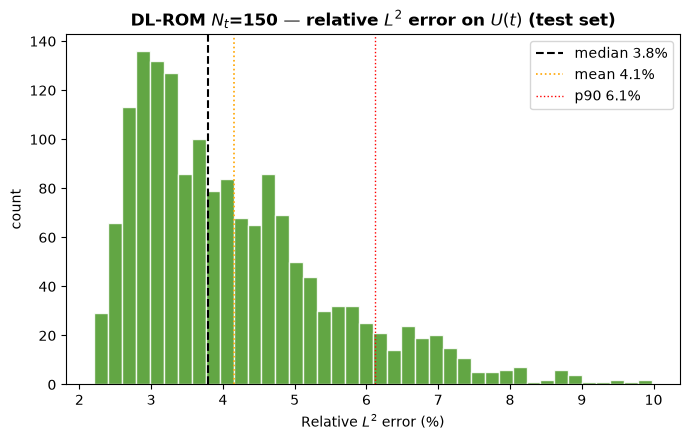

In [9]:
if results:
    _dl = [n for n in results
           if results[n]['model_type'] == 'DLROMModel' and results[n]['Nt_eff'] == NT_FULL]
    if _dl:
        l2 = results[_dl[0]]['l2_grid']
        med, mean, p90 = np.nanmedian(l2), np.nanmean(l2), np.nanpercentile(l2, 90)
        fig, ax = plt.subplots(figsize=(7, 4.5))
        ax.hist(l2[~np.isnan(l2)], bins=40, color=PALETTE['DLROMModel'],
                edgecolor='white', alpha=0.88)
        ax.axvline(med,  color='black', ls='--', lw=1.5, label=f'median {med:.1f}%')
        ax.axvline(mean, color='orange', ls=':', lw=1.2, label=f'mean {mean:.1f}%')
        ax.axvline(p90,  color='red',   ls=':', lw=1.0, label=f'p90 {p90:.1f}%')
        ax.set_xlabel('Relative $L^2$ error (%)'); ax.set_ylabel('count')
        ax.set_title('DL-ROM $N_t$=150 — relative $L^2$ error on $U(t)$ (test set)',
                     fontweight='bold')
        ax.legend()
        fig.tight_layout(); fig.savefig('fig_dlrom_nt150_hist.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print('DL-ROM Nt=150 absent from results.')
else:
    print('No results.')

## 8. Coût temporel du surrogate

Pour chaque checkpoint :
- **`N_surr`** = params du MLP surrogate seul (pas le décodeur) = `N_trunk + K·N_head`.
  Attendu ~23.5M à `Nt=150` (DL-ROM) vs ~3.5M à `K=16` (Laplace).
- **Nb de têtes** = `Nt_eff` (DL-ROM) ou `K=16` (Laplace).
- **Facteur de compression temporelle** = `150/Nt_eff` (DL-ROM) ou `150/16≈9.4` (Laplace).

In [10]:
def _compression(r: dict) -> float:
    return NT_FULL / r['n_heads']

if results:
    print(f"{'checkpoint':<40} {'famille':<8} {'κ':>3} {'Nt_eff':>6} {'têtes':>6} "
          f"{'N_surr(M)':>10} {'compr.×':>8}")
    print('-' * 90)
    for name, r in sorted(results.items(), key=lambda kv: -kv[1]['n_heads']):
        print(f"{name:<40} {_family(r['model_type']):<8} {r['kappa']:>3} {r['Nt_eff']:>6} "
              f"{r['n_heads']:>6} {r['n_surr']/1e6:>10.2f} {_compression(r):>8.1f}")
else:
    print('Pas de résultats — checkpoints absents (host GPU distant requis).')

checkpoint                               famille    κ Nt_eff  têtes  N_surr(M)  compr.×
------------------------------------------------------------------------------------------
DLROMModel__dlrom_ld64_Nt150__t4h2       DL-ROM     1    150    150      23.50      1.0
DLROMModel__dlrom_ld64_Nt75__t4h2        DL-ROM     2     75     75      12.15      2.0
DLROMModel__dlrom_ld64_Nt50__t4h2        DL-ROM     3     50     50       8.36      3.0
DLROMModel__dlrom_ld64_Nt30__t4h2        DL-ROM     5     30     30       5.33      5.0
LLAEModel__llae_ld64_K16_g0.0_ll__t4h2   LLAE       1    150     16       3.48      9.4
LLAEModel__llae_ld64_K16_g0.01__t4h2     LLAE       1    150     16       3.48      9.4
SLAEModel__slae_ld64_K16_g0.0_ol__t4h2   SLAE       1    150     16       3.22      9.4
SLAEModel__slae_ld64_K16_g0.01__t4h2     SLAE       1    150     16       3.22      9.4
DLROMModel__dlrom_ld64_Nt15__t4h2        DL-ROM    10     15     15       3.06     10.0


## 9. Benchmark d'inférence — latence (`bs=1`)

Latence par échantillon à `bs=1` (10 warm-up / 50 runs, CUDA events), méthodo
`eval_surrogates`. On mesure en plus trois axes de coût (les axes se contredisent,
*Efficiency Misnomer*, Dehghani 2022) :

- **FLOPs** (`torch.utils.flop_counter`, hardware-indépendant) — décodeur `O(K)` (SLAE)
  vs `O(Nt)` (LLAE/DL-ROM), invisible en params (décodeur partagé).
- **Mémoire GPU pic** (`max_memory_allocated`).
- **Énergie** (NVML/`pynvml`, `E ≈ P̄·Δt/N`).

In [11]:
import time
from torch.utils.flop_counter import FlopCounterMode
try:
    import pynvml
    pynvml.nvmlInit()
    _NVML_H = pynvml.nvmlDeviceGetHandleByIndex(0)
except Exception as _e:
    pynvml = None; _NVML_H = None
    print(f'pynvml indisponible ({_e}) → énergie non mesurée.')

N_WARMUP   = 10
N_RUNS     = 50
E_MIN_TIME = 1.5
E_MIN_ITERS = 60
bench = {}   # name -> dict(lat_med, lat_std, flops, mem_mb, energy_j, power_w)


def _time_gpu(fn, n_warmup, n_runs):
    for _ in range(n_warmup): fn()
    torch.cuda.synchronize()
    ev_s = torch.cuda.Event(enable_timing=True); ev_e = torch.cuda.Event(enable_timing=True)
    ms = []
    for _ in range(n_runs):
        ev_s.record(); fn(); ev_e.record(); torch.cuda.synchronize()
        ms.append(ev_s.elapsed_time(ev_e))
    return np.array(ms)

def _time_cpu(fn, n_warmup, n_runs):
    for _ in range(n_warmup): fn()
    ms = []
    for _ in range(n_runs):
        t0 = time.perf_counter(); fn(); ms.append((time.perf_counter() - t0) * 1e3)
    return np.array(ms)

_time_fn = _time_gpu if device == 'cuda' else _time_cpu

def _peak_mem_mb(fn):
    torch.cuda.synchronize(); torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
    fn(); torch.cuda.synchronize()
    return torch.cuda.max_memory_allocated() / 1024**2

def _flops(fn):
    fc = FlopCounterMode(display=False)
    with fc: fn()
    return float(fc.get_total_flops())

def _energy_gpu(fn, handle, min_time=E_MIN_TIME, min_iters=E_MIN_ITERS):
    torch.cuda.synchronize()
    powers = []; t0 = time.perf_counter(); it = 0
    while True:
        fn(); it += 1
        powers.append(pynvml.nvmlDeviceGetPowerUsage(handle))
        if (time.perf_counter() - t0) >= min_time and it >= min_iters: break
    torch.cuda.synchronize()
    dt = time.perf_counter() - t0
    p = float(np.mean(powers)) / 1000.0
    return p * dt / it, p


for name, ckpt_path in tqdm(ckpt_paths.items(), desc='inference benchmark'):
    if name not in results:
        continue
    try:
        pipe = InferencePipeline.from_checkpoint(ckpt_path, device=device)
        tmean = torch.tensor(pipe.ckpt['theta_mean'], dtype=torch.float32, device=device)
        tstd  = torch.tensor(pipe.ckpt['theta_std'],  dtype=torch.float32, device=device)
        th1 = (torch.tensor(theta_np[test_idx[:1]], dtype=torch.float32, device=device) - tmean) / tstd
        def gen1():
            with torch.no_grad(): pipe.model.generate(th1)

        b = {}
        lat = _time_fn(gen1, N_WARMUP, N_RUNS)
        b['lat_med'] = float(np.median(lat)); b['lat_std'] = float(np.std(lat))
        try:    b['flops'] = _flops(gen1)
        except Exception as e: b['flops'] = np.nan; print(f'  {name} FLOPs KO: {e}')
        if device == 'cuda':
            try:    b['mem_mb'] = _peak_mem_mb(gen1)
            except Exception as e: b['mem_mb'] = np.nan; print(f'  {name} mem KO: {e}')
            if pynvml is not None:
                try:    b['energy_j'], b['power_w'] = _energy_gpu(gen1, _NVML_H)
                except Exception as e: b['energy_j'] = np.nan; b['power_w'] = np.nan; print(f'  {name} énergie KO: {e}')
            else:   b['energy_j'] = np.nan; b['power_w'] = np.nan
        else:
            b['mem_mb'] = b['energy_j'] = b['power_w'] = np.nan

        bench[name] = b
        print(f'{name:<42} lat={b["lat_med"]:6.1f}±{b["lat_std"]:.1f}ms  flops={b["flops"]/1e9:6.1f}G  '
              f'mem={b.get("mem_mb",np.nan):5.0f}MB  E={b.get("energy_j",np.nan)*1e3:5.1f}mJ')
        pipe.model.cpu(); del pipe
        if device == 'cuda': torch.cuda.empty_cache()
        gc.collect()
    except Exception as e:
        print(f'{name}  ERROR: {e}')

print('\nDone.')

inference benchmark:   0%|          | 0/9 [00:00<?, ?it/s]

/tmp/ipykernel_2230530/529142905.py:65: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tmean = torch.tensor(pipe.ckpt['theta_mean'], dtype=torch.float32, device=device)
/tmp/ipykernel_2230530/529142905.py:66: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tstd  = torch.tensor(pipe.ckpt['theta_std'],  dtype=torch.float32, device=device)


DLROMModel__dlrom_ld64_Nt150__t4h2         lat=  60.3±20.9ms  flops=  48.3G  mem=  927MB  E=8715.7mJ


inference benchmark:  11%|█         | 1/9 [00:14<01:52, 14.06s/it]/tmp/ipykernel_2230530/529142905.py:65: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tmean = torch.tensor(pipe.ckpt['theta_mean'], dtype=torch.float32, device=device)
/tmp/ipykernel_2230530/529142905.py:66: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tstd  = torch.tensor(pipe.ckpt['theta_std'],  dtype=torch.float32, device=device)


DLROMModel__dlrom_ld64_Nt75__t4h2          lat=  51.8±16.7ms  flops=  24.1G  mem=  491MB  E=4602.9mJ


...

LLAEModel__llae_ld64_K16_g0.01__t4h2       lat=  73.3±9.1ms  flops=  48.2G  mem=  622MB  E=11758.6mJ


inference benchmark:  89%|████████▉ | 8/9 [00:59<00:07,  7.34s/it]

SLAEModel__slae_ld64_K16_g0.0_ol__t4h2     lat=  28.4±10.4ms  flops=  30.3G  mem=  235MB  E=4719.6mJ


inference benchmark: 100%|██████████| 9/9 [01:04<00:00,  7.21s/it]

SLAEModel__slae_ld64_K16_g0.01__t4h2       lat=  29.0±11.0ms  flops=  30.3G  mem=  235MB  E=4993.5mJ

Done.


## 10. Benchmark — latency (bar chart)

Per-sample latency at `bs=1` (10 warm-up / 50 CUDA-Event runs), DL-ROM at $N_t=150$.

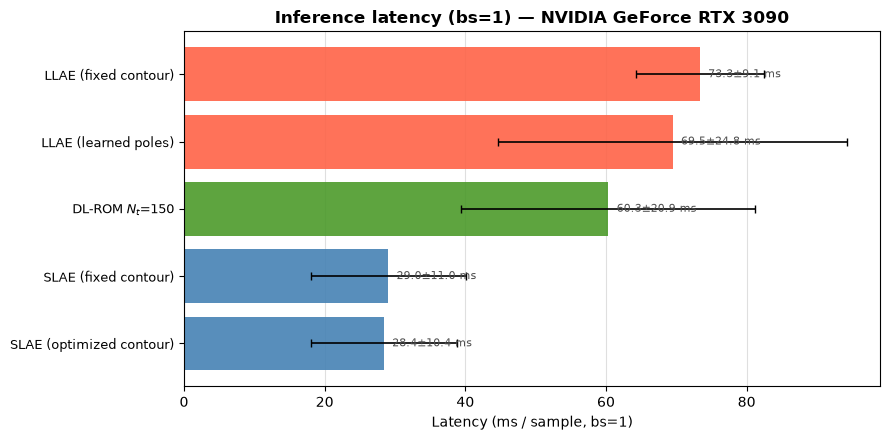

In [12]:
if bench and results:
    pw = [n for n in _pointwise_names(results) if n in bench]
    tags = sorted(pw, key=lambda t: bench[t]['lat_med'])
    cols = [PALETTE.get(results[t]['model_type'], 'gray') for t in tags]

    fig, ax = plt.subplots(figsize=(9, 0.6 * len(tags) + 1.5))
    y = np.arange(len(tags))
    lats = [bench[t]['lat_med'] for t in tags]; stds = [bench[t]['lat_std'] for t in tags]
    ax.barh(y, lats, color=cols, alpha=0.9, zorder=2)
    ax.errorbar(lats, y, xerr=stds, fmt='none', color='black', capsize=3, lw=1.2, zorder=3)
    ax.set_yticks(y); ax.set_yticklabels([_mk(t)['tag'] for t in tags], fontsize=9)
    for yi, (l, s) in enumerate(zip(lats, stds)):
        ax.annotate(f'{l:.1f}±{s:.1f} ms', (l, yi), textcoords='offset points',
                    xytext=(6, 0), va='center', fontsize=8, color='0.3')
    ax.set_xlabel('Latency (ms / sample, bs=1)')
    gpu = torch.cuda.get_device_name(0) if device == 'cuda' else 'CPU'
    ax.set_title(f'Inference latency (bs=1) — {gpu}', fontweight='bold')
    ax.grid(axis='x', alpha=0.4, zorder=0)
    fig.tight_layout(); fig.savefig('fig_dlrom_bench.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No bench — skipped.')

## 11. Table — DL-ROM + réf Laplace

Lignes `Nt` (+`κ`, +compression `150/Nt`, +`N_surr`, +latence, +médiane/p90 **iso-grille**) ;
lignes de référence en bas : LLAE-K16, SLAE-K16, (POD). Métrique **iso-grille** uniquement
(grille native, sans interpolation) — la résolution de sortie est portée par la colonne `Nt`.

In [13]:
if results:
    def _row(name, r):
        g    = r['l2_grid']
        lat  = bench.get(name, {}).get('lat_med', np.nan)
        return dict(
            fam    = _family(r['model_type']),
            Nt     = r['Nt_eff'],
            kappa  = r['kappa'],
            compr  = _compression(r),
            surrM  = r['n_surr'] / 1e6,
            lat    = lat,
            g_med  = np.nanmedian(g),  g_p90 = np.nanpercentile(g, 90),
        )

    dl_rows  = [(n, _row(n, r)) for n, r in results.items() if r['model_type'] == 'DLROMModel']
    lap_rows = [(n, _row(n, r)) for n, r in results.items()
                if r['model_type'] in ('LLAEModel', 'SLAEModel')]
    dl_rows.sort(key=lambda kv: -kv[1]['Nt'])
    lap_rows.sort(key=lambda kv: kv[1]['fam'])

    hdr = (f"{'modèle':<14}{'Nt':>4}{'κ':>4}{'compr×':>8}{'N_surr(M)':>11}"
           f"{'lat(ms)':>9}{'grille med':>12}{'grille p90':>12}")
    print(hdr); print('-' * len(hdr))
    def _pr(tag, d):
        lat = f"{d['lat']:>9.1f}" if np.isfinite(d['lat']) else f"{'—':>9}"
        print(f"{tag:<14}{d['Nt']:>4}{d['kappa']:>4}{d['compr']:>8.1f}{d['surrM']:>11.2f}"
              f"{lat}{d['g_med']:>11.2f}%{d['g_p90']:>11.2f}%")
    for _, d in dl_rows:
        _pr(f"DL-ROM Nt{d['Nt']}", d)
    print('-' * len(hdr))
    for _, d in lap_rows:
        _pr(f"{d['fam']}-K16", d)
    print(f"{'POD surrogate':<14}{'—':>4}{'—':>4}{'—':>8}{'—':>11}{'—':>9}"
          f"{POD_REF_MEDIAN:>11.2f}%{'—':>11}")

    # DataFrame optionnel (si pandas dispo)
    try:
        import pandas as pd
        rows = ([dict(model=f"DL-ROM Nt{d['Nt']}", **d) for _, d in dl_rows] +
                [dict(model=f"{d['fam']}-K16", **d) for _, d in lap_rows])
        df = pd.DataFrame(rows)[['model', 'Nt', 'kappa', 'compr', 'surrM', 'lat',
                                 'g_med', 'g_p90']]
        display(df.round(2))
    except Exception:
        pass
else:
    print('Pas de résultats — table sautée.')

modèle          Nt   κ  compr×  N_surr(M)  lat(ms)  grille med  grille p90
--------------------------------------------------------------------------
DL-ROM Nt150   150   1     1.0      23.50     60.3       3.80%       6.12%
DL-ROM Nt75     75   2     2.0      12.15     51.8       3.97%       6.40%
DL-ROM Nt50     50   3     3.0       8.36     23.5       3.84%       6.19%
DL-ROM Nt30     30   5     5.0       5.33     14.8       3.86%       6.30%
DL-ROM Nt15     15  10    10.0       3.06      6.7       3.73%       5.98%
--------------------------------------------------------------------------
LLAE-K16       150   1     9.4       3.48     69.5       4.63%       7.65%
LLAE-K16       150   1     9.4       3.48     73.3       4.06%       6.48%
SLAE-K16       150   1     9.4       3.22     28.4       7.46%      13.38%
SLAE-K16       150   1     9.4       3.22     29.0       7.60%       9.50%
POD surrogate    —   —       —          —        —       8.91%          —


## 12. Accuracy vs inference cost

Median relative $L^2$ error (iso-grid, no interpolation) against five cost axes at fixed
150-step output: surrogate **parameters**, **latency**, **peak GPU memory**, **FLOPs**,
**energy**. Bottom-left is best. ★ = learned basis, ◆ = fixed basis; DL-ROM shown at
$N_t=150$ (same task).

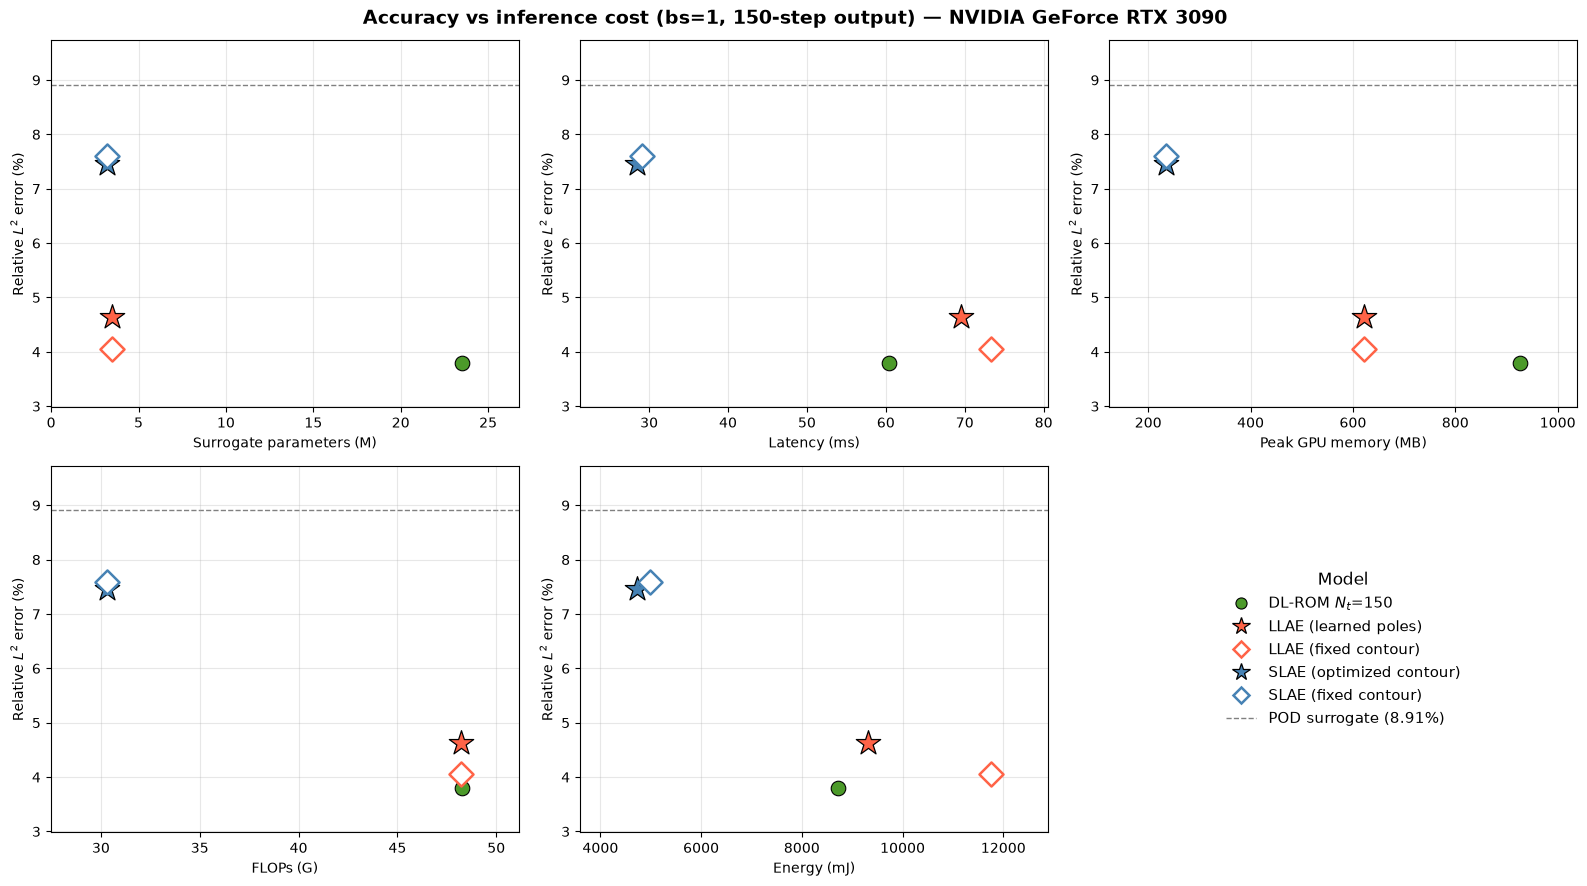

In [14]:
# Accuracy vs cost — 5 panels (DL-ROM at Nt=150 only). Shared legend.
_PW_AXES = [
    ('params',  'Surrogate parameters (M)', 1e-6),
    ('lat_med', 'Latency (ms)',             1.0),
    ('mem_mb',  'Peak GPU memory (MB)',     1.0),
    ('flops',   'FLOPs (G)',                1e-9),
    ('energy_j','Energy (mJ)',              1e3),
]

def _cost(n, k, sc):
    if k == 'params':
        return results[n]['n_surr'] * sc
    v = bench.get(n, {}).get(k, np.nan)
    return v * sc if np.isfinite(v) else np.nan

if bench and results:
    pw = [n for n in _pointwise_names(results) if n in bench]
    fig, axs = plt.subplots(2, 3, figsize=(16, 9)); axs = axs.reshape(-1)
    for ax, (k, lab, sc) in zip(axs, _PW_AXES):
        for n in pw:
            x = _cost(n, k, sc)
            if not np.isfinite(x): continue
            m = _mk(n)
            ax.scatter(x, np.nanmedian(results[n]['l2_grid']), s=m['size'], marker=m['marker'],
                       facecolors=m['face'], edgecolors=m['edge'], lw=m['lw'], zorder=5)
        ax.axhline(POD_REF_MEDIAN, ls='--', color='gray', lw=1.0, zorder=1)
        ax.set_xlabel(lab); ax.set_ylabel('Relative $L^2$ error (%)')
        ax.grid(alpha=0.3); ax.margins(x=0.16, y=0.16)
    # 6e case = légende commune
    axs[5].axis('off')
    handles = [_legend_handle(n) for n in pw]
    handles.append(Line2D([0], [0], ls='--', color='gray', lw=1.0,
                          label=f'POD surrogate ({POD_REF_MEDIAN:.2f}%)'))
    axs[5].legend(handles=handles, loc='center', fontsize=11, frameon=False,
                  title='Model', title_fontsize=12)
    gpu = torch.cuda.get_device_name(0) if device == 'cuda' else 'CPU'
    fig.suptitle(f'Accuracy vs inference cost (bs=1, 150-step output) — {gpu}',
                 fontweight='bold', fontsize=14)
    fig.tight_layout()
    fig.savefig('fig_dlrom_cost_axes.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No bench/results — skipped.')

## 13. Relative cost vs full DL-ROM ($N_t=150$ = 1)

Same 150-step output, cost normalized to DL-ROM $N_t=150$ on each axis. Bars `< 1` are
cheaper than the baseline (log scale).

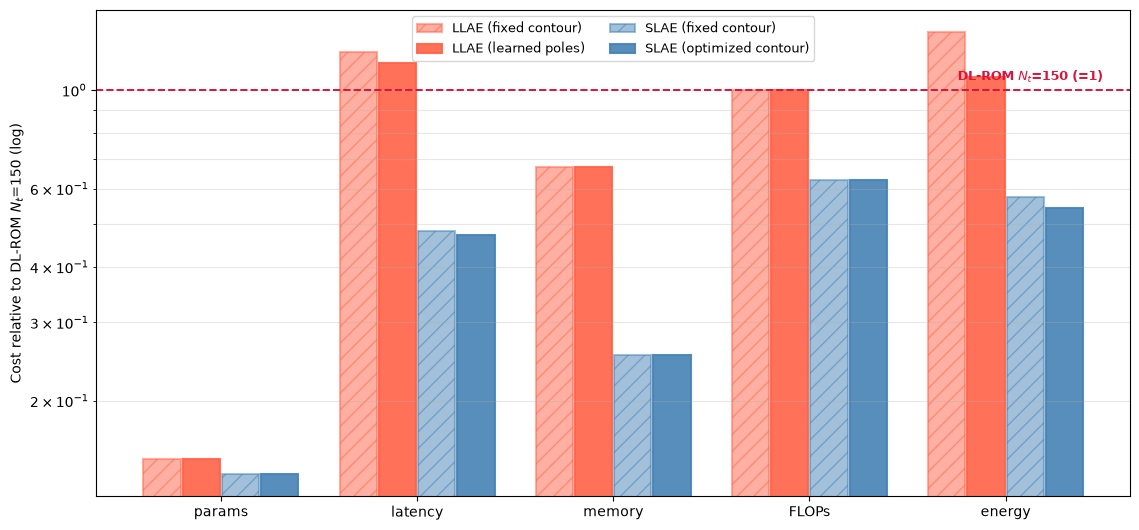

In [15]:
# Cost relative to DL-ROM Nt=150 (=1) on: params, latency, memory, FLOPs, energy.
def _dl150():
    for n, r in results.items():
        if r['model_type'] == 'DLROMModel' and r['Nt_eff'] == NT_FULL: return n
    return None

_ref = _dl150()
if _ref is not None and bench:
    axes_def = [
        ('params',  lambda n: results[n]['n_surr']),
        ('latency', lambda n: bench.get(n, {}).get('lat_med', np.nan)),
        ('memory',  lambda n: bench.get(n, {}).get('mem_mb',  np.nan)),
        ('FLOPs',   lambda n: bench.get(n, {}).get('flops',   np.nan)),
        ('energy',  lambda n: bench.get(n, {}).get('energy_j', np.nan)),
    ]
    ref_v = {lab: g(_ref) for lab, g in axes_def}
    labs = [lab for lab, _ in axes_def if np.isfinite(ref_v[lab]) and ref_v[lab] > 0]
    laps = [n for n in _pointwise_names(results)
            if results[n]['model_type'] in ('LLAEModel', 'SLAEModel') and n in bench]
    laps.sort(key=lambda n: (results[n]['model_type'], _laplace_basis(n)[0]))

    if laps and labs:
        x = np.arange(len(labs)); w = 0.8 / max(len(laps), 1)
        fig, ax = plt.subplots(figsize=(1.7 * len(labs) + 3, 5.4))
        getter = dict(axes_def)
        for i, n in enumerate(laps):
            m = _mk(n)
            ratios = [getter[lab](n) / ref_v[lab] for lab in labs]
            xi = x + (i - (len(laps) - 1) / 2) * w
            ax.bar(xi, ratios, w * 0.95, color=m['c'],
                   alpha=0.5 if m['face'] == 'white' else 0.9, edgecolor=m['c'], lw=1.5,
                   hatch='//' if m['face'] == 'white' else None, label=m['tag'])
        ax.axhline(1.0, color='crimson', lw=1.4, ls='--')
        ax.text(len(labs) - 0.5, 1.05, 'DL-ROM $N_t$=150 (=1)', ha='right',
                color='crimson', fontsize=9, fontweight='bold')
        ax.set_xticks(x); ax.set_xticklabels(labs)
        ax.set_ylabel('Cost relative to DL-ROM $N_t$=150 (log)'); ax.set_yscale('log')
        ax.grid(axis='y', alpha=0.3, which='both')
        ax.legend(fontsize=9, ncol=2, loc='upper center')
        fig.tight_layout(); fig.savefig('fig_dlrom_cost_relative.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print('Missing Laplace refs / cost axes — skipped.')
else:
    print('DL-ROM Nt=150 or bench missing — skipped.')

## 14. Inference cost vs output resolution $N_t$

Laplace pipelines output any $N_t$ from a single $K{=}16$ checkpoint; DL-ROM needs one model
per $N_t$. Cost (params, FLOPs, latency, memory, energy) of one inference vs the requested
number of output steps. **SLAE is flat** (decodes $K{=}16$ frames, decoupled from $N_t$);
LLAE and DL-ROM grow as $O(N_t)$ and overlap in FLOPs (decoder-bound); LLAE wins on params
(fixed surrogate).

In [23]:
# Coût d'inférence vs résolution de sortie Nt (bs=1).
#   DL-ROM  : point unique à son Nt natif (n_frames ignoré).
#   LLAE/SLAE: UN checkpoint, generate(Nt=nt) balayé sur NT_GRID.
cost_nt = {}   # name -> {nt: dict(flops, lat_ms, mem_mb, energy_j)}
_cost_errors = {}

def _measure(gen, name, nt):
    d = {'flops': np.nan, 'lat_ms': np.nan, 'mem_mb': np.nan, 'energy_j': np.nan}
    # 1) sanity : l'inférence tourne-t-elle ? (sinon on logue l'erreur RÉELLE)
    try:
        gen()
    except Exception as e:
        import traceback
        if name not in _cost_errors:
            _cost_errors[name] = f'{type(e).__name__}: {e}'
            print(f'  !! {name} Nt={nt} generate KO -> {type(e).__name__}: {e}')
            traceback.print_exc()
        return d
    try:    d['flops'] = _flops(gen)
    except Exception as e: print(f'  !! {name} Nt={nt} FLOPs KO -> {e}')
    if device == 'cuda':
        try:    d['lat_ms'] = float(np.median(_time_gpu(gen, 5, 30)))
        except Exception as e: print(f'  !! {name} Nt={nt} lat KO -> {e}')
        try:    d['mem_mb'] = _peak_mem_mb(gen)
        except Exception: pass
        if pynvml is not None:
            try:    d['energy_j'] = _energy_gpu(gen, _NVML_H)[0]
            except Exception: pass
    return d

for name, ckpt_path in tqdm(ckpt_paths.items(), desc='coût vs Nt'):
    if name not in results:
        continue
    mt = results[name]['model_type']
    try:
        pipe = InferencePipeline.from_checkpoint(ckpt_path, device=device)
        tmean = torch.tensor(pipe.ckpt['theta_mean'], dtype=torch.float32, device=device)
        tstd  = torch.tensor(pipe.ckpt['theta_std'],  dtype=torch.float32, device=device)
        tn = (torch.tensor(theta_np[test_idx[:1]], dtype=torch.float32, device=device) - tmean) / tstd
        is_lap = mt in ('LLAEModel', 'SLAEModel')
        nts = list(NT_GRID) if is_lap else [results[name]['Nt_eff']]
        cost_nt[name] = {}
        for nt in nts:
            if is_lap:
                def gen(nt=nt, m=pipe.model, tn=tn):
                    with torch.no_grad(): m.generate(tn, Nt=nt)
            else:
                def gen(m=pipe.model, tn=tn):
                    with torch.no_grad(): m.generate(tn)
            cost_nt[name][nt] = _measure(gen, name, nt)
        pipe.model.cpu(); del pipe
        if device == 'cuda': torch.cuda.empty_cache()
        gc.collect()
    except Exception as e:
        print(f'{name}  ERROR: {e}')

# ── Résumé : FLOPs mesurés par modèle (NaN = mesure échouée) ─────────────────
print('\nFLOPs (G) mesurés par Nt :')
for name in cost_nt:
    fl = [cost_nt[name][nt].get('flops', np.nan) / 1e9 for nt in sorted(cost_nt[name])]
    fl_s = ' '.join(f'{v:5.1f}' if np.isfinite(v) else '  nan' for v in fl)
    print(f'  {name:<44} {fl_s}')
if _cost_errors:
    print('\nErreurs generate :', _cost_errors)
print('\nDone.')

coût vs Nt:   0%|          | 0/9 [00:00<?, ?it/s]/tmp/ipykernel_2230530/331102705.py:37: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tmean = torch.tensor(pipe.ckpt['theta_mean'], dtype=torch.float32, device=device)
/tmp/ipykernel_2230530/331102705.py:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tstd  = torch.tensor(pipe.ckpt['theta_std'],  dtype=torch.float32, device=device)
coût vs Nt: 100%|██████████| 9/9 [01:58<00:00, 13.15s/it]


FLOPs (G) mesurés par Nt :
  DLROMModel__dlrom_ld64_Nt150__t4h2            48.3
  DLROMModel__dlrom_ld64_Nt75__t4h2             24.1
  DLROMModel__dlrom_ld64_Nt50__t4h2             16.1
  DLROMModel__dlrom_ld64_Nt30__t4h2              9.7
  DLROMModel__dlrom_ld64_Nt15__t4h2              4.8
  LLAEModel__llae_ld64_K16_g0.0_ll__t4h2         4.8   9.6  16.1  24.1  48.2
  LLAEModel__llae_ld64_K16_g0.01__t4h2           4.8   9.6  16.1  24.1  48.2
  SLAEModel__slae_ld64_K16_g0.0_ol__t4h2        30.2  30.2  30.2  30.3  30.3
  SLAEModel__slae_ld64_K16_g0.01__t4h2          30.2  30.2  30.2  30.3  30.3

Done.


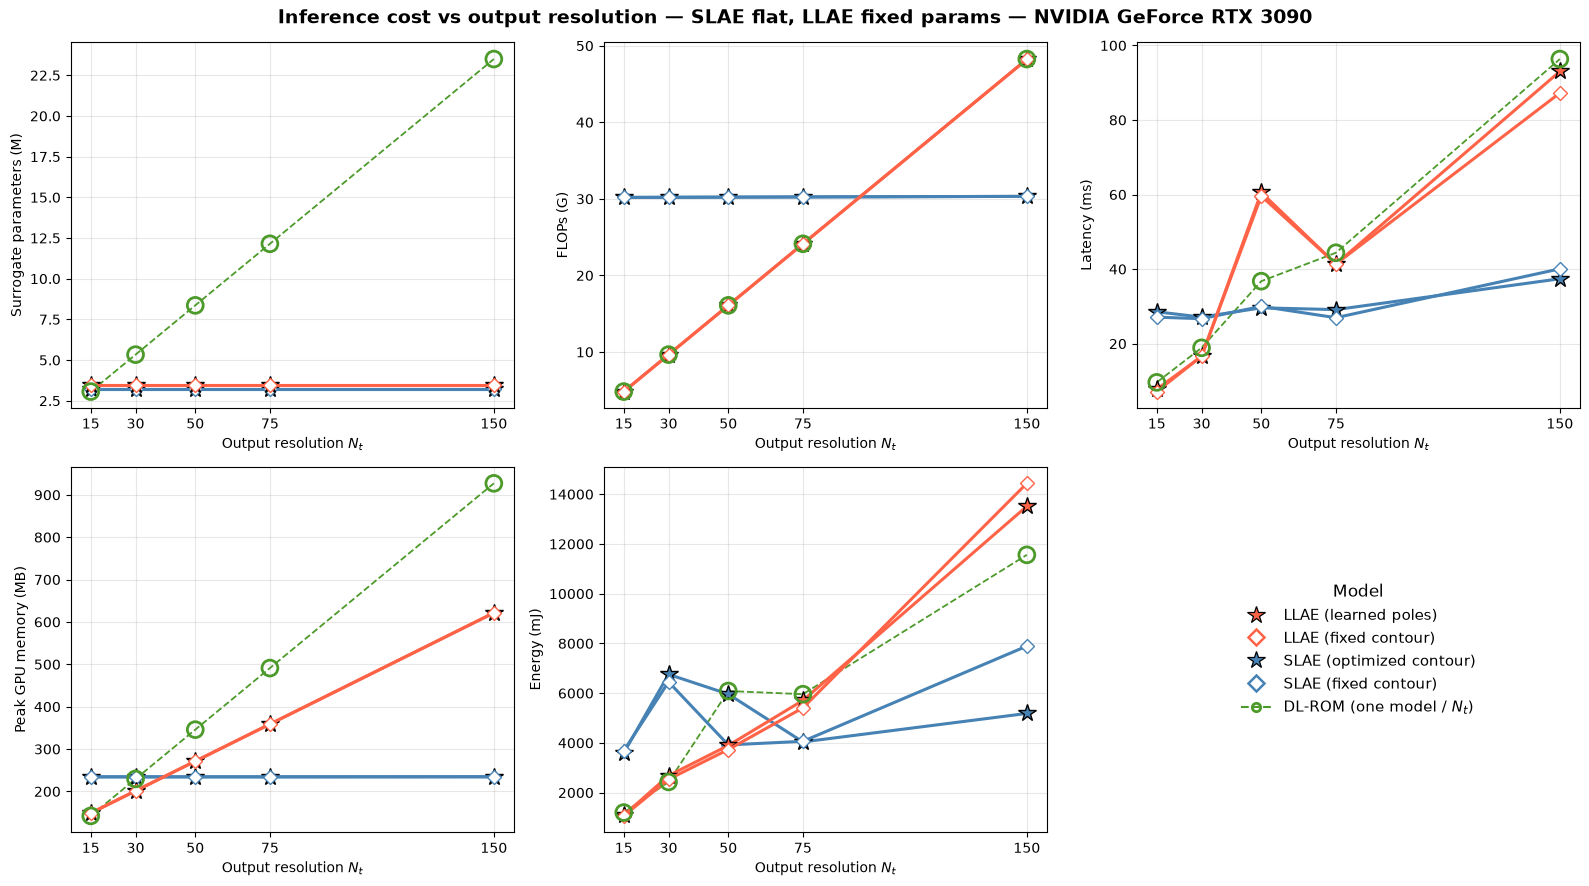

In [24]:
# Cost vs output resolution Nt — 5 panels, shared legend, EN.
_NT_AXES = [
    ('params',  'Surrogate parameters (M)', 1e-6),
    ('flops',   'FLOPs (G)',                1e-9),
    ('lat_ms',  'Latency (ms)',             1.0),
    ('mem_mb',  'Peak GPU memory (MB)',     1.0),
    ('energy_j','Energy (mJ)',              1e3),
]

def _ntval(n, nt, k, sc):
    if k == 'params':
        return results[n]['n_surr'] * sc
    v = cost_nt[n].get(nt, {}).get(k, np.nan)
    return v * sc if np.isfinite(v) else np.nan

if cost_nt:
    common = [n for n in cost_nt if cost_nt[n]]
    laps = [n for n in common if results[n]['model_type'] in ('LLAEModel', 'SLAEModel')]
    dros = [n for n in common if results[n]['model_type'] == 'DLROMModel']
    axes = [(k, lab, sc) for (k, lab, sc) in _NT_AXES
            if k == 'params' or any(np.isfinite(cost_nt[n][nt].get(k, np.nan))
                                    for n in common for nt in cost_nt[n])]
    fig, axs = plt.subplots(2, 3, figsize=(16, 9)); axs = axs.reshape(-1)
    for ax, (k, lab, sc) in zip(axs, axes):
        # DL-ROM : fin pointillé SOUS tout le monde (zorder 2)
        dls = sorted((results[n]['Nt_eff'], _ntval(n, results[n]['Nt_eff'], k, sc)) for n in dros)
        if dls:
            xd, yd = zip(*dls)
            ax.plot(xd, yd, '--', color=PALETTE['DLROMModel'], lw=1.3, zorder=2)
        # Laplace : lignes pleines (SLAE zorder 3, LLAE zorder 4)
        for n in laps:
            m = _mk(n); nts = sorted(cost_nt[n])
            z = 4 if results[n]['model_type'] == 'LLAEModel' else 3
            ax.plot(nts, [_ntval(n, nt, k, sc) for nt in nts], '-', color=m['c'], lw=2.2, zorder=z,
                    marker=m['marker'], markersize=13 if m['marker'] == '*' else 7,
                    markerfacecolor=(m['c'] if m['face'] != 'white' else 'white'),
                    markeredgecolor=(m['c'] if m['face'] == 'white' else 'k'))
        # DL-ROM : ANNEAUX CREUX par-dessus (zorder 6) → la ligne LLAE reste visible dedans
        if dls:
            ax.scatter(xd, yd, s=130, facecolors='none', edgecolors=PALETTE['DLROMModel'],
                       linewidths=2.0, zorder=6)
        ax.set_xlabel('Output resolution $N_t$'); ax.set_ylabel(lab)
        ax.grid(alpha=0.3); ax.set_xticks(NT_GRID)

    # 6e case = legende commune (ordre : LLAE, SLAE, DL-ROM)
    axs[5].axis('off')
    handles = [_legend_handle(n) for n in laps]
    handles.append(Line2D([0], [0], ls='--', color=PALETTE['DLROMModel'], marker='o',
                          markerfacecolor='none', markeredgecolor=PALETTE['DLROMModel'],
                          markeredgewidth=2.0, label='DL-ROM (one model / $N_t$)'))
    axs[5].legend(handles=handles, loc='center', fontsize=11, frameon=False,
                  title='Model', title_fontsize=12)
    gpu = torch.cuda.get_device_name(0) if device == 'cuda' else 'CPU'
    fig.suptitle(f'Inference cost vs output resolution — SLAE flat, LLAE fixed params — {gpu}',
                 fontweight='bold', fontsize=13.5)
    fig.tight_layout(); fig.savefig('fig_dlrom_cost_vs_nt.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('cost_nt empty — skipped.')